# L15d: Graph Classification with Graph Neural Networks (GNNs)
In this lab, we apply a Graph Neural Network (GNN) to a graph classification task on the [MUTAG dataset](https://chrsmrrs.github.io/datasets/) of 188 nitroaromatic molecules, predicting their mutagenic effect on _Salmonella typhimurium_. We build a custom message-passing convolutional layer using [the `GraphNeuralNetworks.jl` package](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/), train the model with [the `Flux.jl` package](https://fluxml.ai/), and study how the model's hyperparameters affect test accuracy.

For background on GNNs, see the Stanford course [CS224W: Machine Learning with Graphs](https://web.stanford.edu/class/cs224w/). The full 2023 lectures are also available on [YouTube](https://www.youtube.com/watch?v=ZfK4FDk9uy8&list=PLlweTYMJoEmfttflTmuIqf9WSTQw9h-Io).

> __Learning Objectives.__ After working through this notebook you should be able to:
>
> * __Represent graph-structured data for learning:__ Encode a dataset of graphs with categorical node attributes into tensors a neural network can consume. Mini-batch variable-sized graphs without padding by treating a batch as one larger graph composed of disconnected components.
> * __Build a message-passing layer from its primitives:__ Define a neighborhood update by composing a per-edge message function, a permutation-invariant neighbor aggregator, and a node-level update. Stack such layers and attach a graph-level readout to turn per-node features into per-graph predictions.
> * __Reason about hyperparameter sensitivity:__ Run a controlled sweep around a baseline configuration and read the results to identify which knob most affects generalization. Distinguish hyperparameters that change model capacity, regularization, and optimization noise.

Let's get started!
___

## Task 1: Setup, Data, Prerequisites
In this task, we set up the computational environment by including the `Include.jl` file, load the [MUTAG dataset](https://chrsmrrs.github.io/datasets/) of `188` molecular graphs, one-hot encode the per-node atom-type labels, and randomly split the graphs into a training set of `150` and a test set of `38`.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of `Include.jl` in the notebook's global scope. The `Include.jl` file sets paths, loads the required external packages ([`Flux.jl`](https://fluxml.ai/Flux.jl/stable/), [`GraphNeuralNetworks.jl`](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/), [`MLDatasets.jl`](https://juliaml.github.io/MLDatasets.jl/stable/), [`GraphMakie.jl`](https://github.com/MakieOrg/GraphMakie.jl), [`JLD2.jl`](https://github.com/JuliaIO/JLD2.jl), [`PrettyTables.jl`](https://github.com/ronisbr/PrettyTables.jl), and [`DataFrames.jl`](https://dataframes.juliadata.org/stable/)), and includes our local source files in `src/`. It checks for a `Manifest.toml`; if one is found, packages are loaded directly, otherwise the environment is instantiated.

In [1]:
include("Include.jl");

### Data
One common task for graph neural networks is the graph classification problem, e.g., a molecular property prediction task in which molecules are represented as graphs. The task may be to infer whether a molecule inhibits HIV replication or not. In this case, we'll look at the data to predict the antimicrobial activity of small molecules.

The [TU Dortmund University](https://www.tu-dortmund.de/en/) has collected a wide range of different graph classification datasets, known as the [TUDatasets](https://chrsmrrs.github.io/datasets/), which are [accessible via the  `MLDatasets.jl` package](https://juliaml.github.io/MLDatasets.jl/stable/). Let's load and inspect one of the smaller ones, the __MUTAG dataset__:

In [2]:
dataset = TUDataset("MUTAG"); # download the dataset

__What's in the dataset variable?__

The MUTAG dataset [from TU Dortmund University](https://www.tu-dortmund.de/en/) is a collection of `188` nitroaromatic compounds represented as graphs, labeled according to their mutagenic effect on the bacterium _Salmonella typhimurium_. Each graph carries a single binary mutagenicity label in $\{-1, +1\}$, plus per-node atom-type labels in $\{0, 1, \ldots, 6\}$ (7 classes) and per-edge bond-type labels (4 classes). For simplicity, we ignore the edge labels in this lab.

The [`GraphNeuralNetworks.jl` package](https://github.com/JuliaGraphs/GraphNeuralNetworks.jl.git) provides utilities for working with graph datasets. Let's dig into the code block below.

* The [`mldataset2gnngraph(...)` method](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/GNNGraphs/api/datasets/#GNNGraphs.mldataset2gnngraph) converts a graph dataset from [the `MLDatasets.jl` package](https://juliaml.github.io/MLDatasets.jl/stable/) into one or many [`GNNGraph` instances](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/GNNGraphs/api/gnngraph/#GNNGraphs.GNNGraph). Since MUTAG contains multiple graphs, we get a `Vector{GNNGraph}` of length `188`.
* For each graph, we then build a fresh [`GNNGraph`](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/GNNGraphs/api/gnngraph/#GNNGraphs.GNNGraph) whose node feature matrix `ndata` is the one-hot encoding of the atom-type labels via [the `onehotbatch(...)` method from `Flux.jl`](https://fluxml.ai/Flux.jl/stable/reference/data/onehot/#OneHotArrays.onehotbatch). Each node therefore carries a 7-dimensional `Float32` feature vector. We drop edge features (`edata=nothing`).
* We split the dataset into training and test sets by randomly permuting indices with [the `randperm(...)` method from `Random.jl`](https://docs.julialang.org/en/v1/stdlib/Random/#Random.randperm); the first `number_of_training_graphs = 150` indices form the training set and the remaining `38` form the test set.
* The graph-level mutagenicity labels are one-hot encoded into `ytrain` and `ytest` with two rows (one per class in $\{-1, +1\}$) using [`onehotbatch(...)`](https://fluxml.ai/Flux.jl/stable/reference/data/onehot/#OneHotArrays.onehotbatch).

In [3]:
raw_graphs_array = mldataset2gnngraph(dataset) # convert to GNNGraph instances, see documentation about this type.
graphs = [GNNGraph(g, ndata=Float32.(onehotbatch(g.ndata.targets, 0:6)), edata=nothing) for g ∈ raw_graphs_array]; # one hot encode the node labels

# build random training and test sets -
number_of_training_graphs = 150;
shuffled_indexes = randperm(length(graphs)) # shuffle the dataset using randperm
training_indexes = shuffled_indexes[1:number_of_training_graphs];
testing_indexes = shuffled_indexes[(number_of_training_graphs+1):end];
training_graphs = graphs[training_indexes]; # we'll use these graphs for training
testing_graphs = graphs[testing_indexes]; # we'll use these graphs for testing
ytrain = onehotbatch(dataset.graph_data.targets[training_indexes], [-1, 1])
ytest = onehotbatch(dataset.graph_data.targets[testing_indexes], [-1, 1]);

__What's in our test and training set?__

The graph-level labels for the training and test sets are stored as [a `OneHotMatrix`](https://fluxml.ai/Flux.jl/stable/reference/data/onehot/), where the $k$-th column is the one-hot encoding of the label of the $k$-th graph against the class set `[-1, +1]`. The first row indicates class `-1` (non-mutagenic) and the second row indicates class `+1` (mutagenic). Let's look at the label of the second training graph below.

In [4]:
ytrain[:,2] # row 1: false, row 2: true

2-element OneHotVector(::UInt32) with eltype Bool:
 1
 ⋅

Let's visualize a graph from the training set. In the code block below we use [the `GraphMakie.jl` package](https://github.com/MakieOrg/GraphMakie.jl/tree/master), a wrapper around [`Makie.jl`](https://github.com/MakieOrg/Makie.jl), to draw a `GNNGraph` with [the `graphplot(...)` method](https://graph.makie.org/stable/#GraphMakie.graphplot). The default layout is functional but not optimized; the goal here is just to confirm the molecule's connectivity is sensible.

GNNGraph(25, 56) with x: 7×25 data


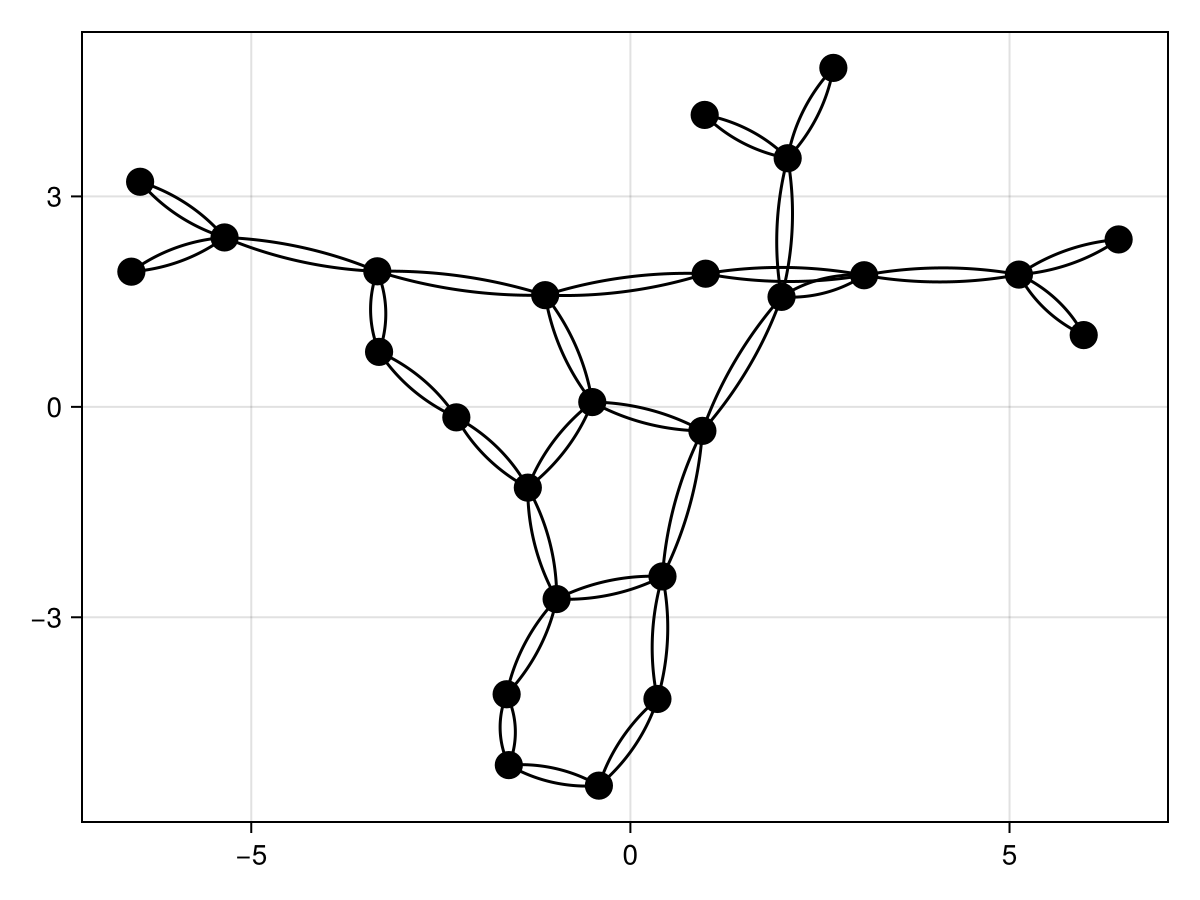

In [5]:
let
    index_of_graph_to_visualize = 22; # what graph to visualize?
    println(training_graphs[index_of_graph_to_visualize])
    GraphMakie.graphplot(training_graphs[index_of_graph_to_visualize], node_size = 20, arrow_show = false);
end

### Things to think about
* __Why one-hot encode the atom-type labels instead of feeding the raw integer in $\{0, 1, \ldots, 6\}$?__ The integer label is a categorical identifier (carbon vs. nitrogen vs. oxygen etc.), not an ordinal quantity. Using the raw integer would force the linear weight $\mathbf{W}_1 \mathbf{x}$ to encode atom identity along a single direction in feature space, implicitly imposing distance relations like $|\text{C} - \text{N}| < |\text{C} - \text{O}|$ that have no chemical meaning. Why does one-hot encoding remove this artifact, and what does it cost in the input dimension `nin`?

## Task 2: Mini-batching, model construction, and training
In this task, we mini-batch the training and test graphs with [the `DataLoader` type](https://github.com/JuliaML/MLUtils.jl), build a three-layer GNN from the custom [`MyCustomConvolutionLayerModel`](src/Types.jl) layer, and train it for `200` epochs using [`Adam`](https://fluxml.ai/Flux.jl/stable/training/optimisers/#Flux.Optimise.Adam) with logit cross-entropy loss.

> __Why mini-batch graphs?__
>
> Graphs in classification datasets are usually small, so processing them one-at-a-time wastes parallelism. In the image or language domain, mini-batching is achieved by **rescaling** or **padding** examples to equal shape and stacking them along an extra dimension. Both options are awkward for graphs: rescaling distorts structure, and padding wastes memory on dummy nodes and edges.
>
> [`GraphNeuralNetworks.jl`](https://github.com/JuliaGraphs/GraphNeuralNetworks.jl) instead **stacks adjacency matrices block-diagonally**, producing a single large graph that contains the batch's graphs as disconnected components, and concatenates the node feature matrices along the node dimension. This way, message passing is run once on the giant graph and per-graph readout is recovered at the pooling step.

The [`DataLoader` type from `MLUtils.jl`](https://github.com/JuliaML/MLUtils.jl) implicitly calls [the `Flux.batch(...)` method](https://fluxml.ai/Flux.jl/stable/reference/data/mlutils/#MLUtils.batch) on the graphs to do this stacking automatically when `collate=true`.

In [6]:
batchsize_for_training = 64; # TODO: what happens if we change the batchsize for training?
batchsize_for_testing = 10; # batchsize for testing
train_loader = DataLoader((training_graphs, ytrain), batchsize=batchsize_for_training, shuffle=true, collate=true)
test_loader = DataLoader((testing_graphs, ytest), batchsize=batchsize_for_testing, shuffle=false, collate=true)

4-element DataLoader(::Tuple{Vector{GNNGraph{Tuple{Vector{Int64}, Vector{Int64}, Nothing}}}, OneHotArrays.OneHotMatrix{UInt32, Vector{UInt32}}}, batchsize=10, collate=Val{true}())
  with first element:
  (GNNGraph{Tuple{Vector{Int64}, Vector{Int64}, Nothing}}, 2×10 OneHotMatrix(::Vector{UInt32}) with eltype Bool,)

__What just happened?__ Let's dig into what came back to figure out what the batching operation is doing. We inspect the `train_loader` fields, then look at the underlying `data[1]` array of `GNNGraph` instances that the loader will batch on the fly.

In [7]:
fieldnames(typeof(train_loader))

(:data, :_data, :batchsize, :buffer, :partial, :shuffle, :parallel, :collate, :rng)

In [8]:
train_loader.data[1]

150-element Vector{GNNGraph{Tuple{Vector{Int64}, Vector{Int64}, Nothing}}}:
 GNNGraph(21, 46) with x: 7×21 data
 GNNGraph(13, 28) with x: 7×13 data
 GNNGraph(19, 44) with x: 7×19 data
 GNNGraph(26, 60) with x: 7×26 data
 GNNGraph(13, 28) with x: 7×13 data
 GNNGraph(13, 28) with x: 7×13 data
 GNNGraph(15, 34) with x: 7×15 data
 GNNGraph(14, 28) with x: 7×14 data
 GNNGraph(11, 22) with x: 7×11 data
 GNNGraph(11, 22) with x: 7×11 data
 ⋮
 GNNGraph(16, 34) with x: 7×16 data
 GNNGraph(16, 34) with x: 7×16 data
 GNNGraph(23, 54) with x: 7×23 data
 GNNGraph(25, 56) with x: 7×25 data
 GNNGraph(12, 26) with x: 7×12 data
 GNNGraph(15, 32) with x: 7×15 data
 GNNGraph(17, 38) with x: 7×17 data
 GNNGraph(19, 44) with x: 7×19 data
 GNNGraph(22, 50) with x: 7×22 data

### Build and train the GNN model
Now that the data is mini-batched, we set the dimensional constants for the model: the input feature dimension `nin`, the hidden width `nh`, and the output (class) dimension `nout`. See the comments in the code block for permissible values and what each constant controls.

In [9]:
nin = 7 # dimension of the node feature vectors for each node
nout = 2 # output dimension for the system. Number of classes (in this case binary)
nh = 32 # TODO: What happens if we change the number of hidden units

32

__Next, let's define and train the GNN model.__ We use a custom [`MyCustomConvolutionLayerModel` layer](src/Types.jl) defined in `src/Types.jl`, with a forward pass implemented in [`src/Compute.jl`](src/Compute.jl) using [`apply_edges`](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/GNNGraphs/api/messagepassing/#GNNlib.apply_edges) and [`aggregate_neighbors`](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/GNNGraphs/api/messagepassing/#GNNlib.aggregate_neighbors). The update rule is:
$$
\begin{align*}
\mathbf{x}_i^{(\ell+1)} & = \sigma\left(\overbrace{\mathbf{W}^{(\ell + 1)}_1 \mathbf{x}_i^{(\ell)}}^{me} +\underbrace{\mathbf{W}^{(\ell + 1)}_2 \sum_{j \in \mathcal{N}(i)} \mathbf{x}_j^{(\ell)}}_{my~neighbors~aggregation} + \mathbf{b}^{(\ell+1)}\right) \\
\end{align*}
$$
where $\mathbf{W}^{(\ell + 1)}_1, \mathbf{W}^{(\ell + 1)}_2 \in \mathbb{R}^{n_h \times n_{in}}$ are the learnable weight matrices of the layer, $\mathbf{b}^{(\ell+1)} \in \mathbb{R}^{n_h}$ is a per-layer bias vector that is broadcast across nodes, $\sigma$ is a non-linear activation function (e.g., ReLU), $\mathbf{x}_i^{(\ell)}$ is the feature vector of node $i$ at layer $\ell$, and $\mathcal{N}(i)$ is the set of neighbors of node $i$.

* _Alternatives to this update rule?_ Yes. The [GraphSAGE](https://arxiv.org/abs/1706.02216) model uses a different aggregation function that combines the features of a node and its neighbors in a different way, and the [Graph Attention Network (GAT)](https://arxiv.org/abs/1710.10903) model uses an attention mechanism to weight the importance of each neighbor's features when aggregating them.
* Multiple papers, e.g., [Xu et al. (2018)](https://arxiv.org/abs/1810.00826), pointed out that applying neighborhood normalization decreases the expressivity of GNNs in distinguishing certain graph structures. As a workaround, [Morris et al. (2018)](https://arxiv.org/abs/1810.02244) omits neighborhood normalization completely and adds a simple skip-connection to the GNN layer to preserve central node information.

Many directions are possible. For now, we use the update rule above, then play with architectural choices in Task 3.

In the code block below we register the custom layer with [`Flux.@layer`](https://fluxml.ai/Flux.jl/stable/reference/models/advanced/#Custom-multi-input-or-multi-output-layer), stack three convolutional stages followed by a [`GlobalPool(mean)`](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/GraphNeuralNetworks/api/pool/#GraphNeuralNetworks.GlobalPool) graph-level readout, a [`Dropout`](https://fluxml.ai/Flux.jl/stable/reference/models/layers/#Flux.Dropout) regularizer, and a [`Dense`](https://fluxml.ai/Flux.jl/stable/reference/models/layers/#Flux.Dense) classifier into a [`GNNChain`](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/GraphNeuralNetworks/api/basic/#GraphNeuralNetworks.GNNChain), and call [the `train!(...)` method](src/Compute.jl) for `200` epochs. Train and test loss/accuracy are reported every `10` epochs.

In [10]:
mymodel = let

	# Flux.@layer is registered for MyCustomConvolutionLayerModel in src/Compute.jl

	inputlayer  = MyCustomConvolutionLayerModel(nin => nh, relu);
	hiddenlayer = MyCustomConvolutionLayerModel(nh => nh, relu);
	outputlayer = MyCustomConvolutionLayerModel(nh => nh);

	model = GNNChain(
				input = inputlayer,
				hidden = hiddenlayer,
				output = outputlayer,
				pool = GlobalPool(mean),    # graph-level readout (mean over per-graph nodes)
				dropout = Dropout(0.5),     # randomly zero half the readout features at training time
				dense = Dense(nh, nout));

	train!(model)
	model; # return the trained model
end;

# epoch = 0
train = (loss = 0.6088, acc = 68.67)
test = (loss = 0.7633, acc = 57.89)
# epoch = 10
train = (loss = 0.4123, acc = 78.67)
test = (loss = 0.6401, acc = 68.42)
# epoch = 20
train = (loss = 0.3756, acc = 80.67)
test = (loss = 0.5998, acc = 68.42)
# epoch = 30
train = (loss = 0.3959, acc = 81.33)
test = (loss = 0.7419, acc = 63.16)
# epoch = 40
train = (loss = 0.3235, acc = 85.33)
test = (loss = 0.6358, acc = 71.05)
# epoch = 50
train = (loss = 0.3369, acc = 86.0)
test = (loss = 0.4599, acc = 84.21)
# epoch = 60
train = (loss = 0.2975, acc = 86.67)
test = (loss = 0.5439, acc = 73.68)
# epoch = 70
train = (loss = 0.2058, acc = 91.33)
test = (loss = 0.3883, acc = 81.58)
# epoch = 80
train = (loss = 0.182, acc = 91.33)
test = (loss = 0.3209, acc = 84.21)
# epoch = 90
train = (loss = 0.1816, acc = 91.33)
test = (loss = 0.2891, acc = 84.21)
# epoch = 100
train = (loss = 0.172, acc = 92.0)
test = (loss = 0.3316, acc = 84.21)
# epoch = 110
train = (loss = 0.2957, acc = 88.67)
test = 

Let's inspect the trained model. The first input layer has fields `W1`, `W2`, `b`, `act`, matching the update rule above. The bias vector `b` is shared across all nodes within a layer (length `nh`).

In [11]:
fieldnames(typeof(mymodel[:input])) # what are the fields in the input layer?

(:W1, :W2, :b, :act)

In [12]:
mymodel[:input].b

32-element Vector{Float32}:
  0.23678048
 -0.1584229
 -0.13580605
 -0.112190254
 -0.031794097
  0.12925674
 -0.18140444
  0.10026329
  0.039597586
 -0.11828383
  ⋮
 -0.12938064
  0.22614498
  0.1129302
  0.0
  0.042487536
 -0.1254742
  0.014638401
  0.08043179
 -0.010104328

### Things to think about
* __Why is `GlobalPool(mean)` necessary in this model?__ The three convolutional stages produce a node feature matrix of shape `(nh, total_nodes_in_batch)`, where the column count varies by batch because each molecule has a different number of atoms. The trailing `Dense(nh, nout)` classifier expects a fixed-shape input of one column per graph, not one column per node. What does [`GlobalPool(mean)`](https://juliagraphs.org/GraphNeuralNetworks.jl/docs/GraphNeuralNetworks.jl/stable/GraphNeuralNetworks/api/pool/#GraphNeuralNetworks.GlobalPool) compute to bridge this gap, and why does the choice of pooling operator (e.g., `mean` vs. `+` vs. `max`) matter for graph classification?

___
## Task 3: Hyperparameter sweep
In this task, we measure how the GNN's test accuracy on MUTAG responds to changes in the hidden width `nh`, the dropout probability, and the training batch size. We use a one-at-a-time design: starting from a baseline configuration, we change one hyperparameter at a time and record the final train and test classification accuracy after `200` epochs.

> __Why a one-at-a-time sweep instead of a full grid?__
>
> A full grid over $|nh| \times |\text{dropout}| \times |\text{batchsize}|$ would explode in cost; a one-at-a-time sweep around a baseline costs $1 + \sum_i (|S_i| - 1)$ runs and is enough to compare each hyperparameter's marginal effect on the same baseline. Interactions between hyperparameters are missed by this design, which is a valid concern but one we ignore here for time.

The sweep is implemented by [the `train_one_config(...)` function](src/Compute.jl), which builds its own [`DataLoader`](https://github.com/JuliaML/MLUtils.jl) instances and a fresh model via [the `build_model(...)` function](src/Compute.jl), trains for `epochs_sweep` epochs, and returns the final train and test classification accuracies.

> __Cached results.__ Training each configuration takes ~30 seconds on a CPU; running all `5` configurations live would consume most of the lab period. The sweep results are cached in `data/L15d_sweep_results.jld2` via [the `JLD2.jl` package](https://github.com/JuliaIO/JLD2.jl). The code block below loads the cached results if the file exists, otherwise it runs the sweep and writes the file. To force a re-run, delete the file.

In [13]:
# Sweep configurations: one-at-a-time around a baseline.
# Baseline: nh=32, dropout_p=0.5, batchsize=64, η=1e-2.
epochs_sweep = 200;
sweep_configs = [
    (label = "baseline",       nh = 32, dropout_p = 0.5, batchsize = 64),
    (label = "nh=16",          nh = 16, dropout_p = 0.5, batchsize = 64),
    (label = "nh=64",          nh = 64, dropout_p = 0.5, batchsize = 64),
    (label = "dropout_p=0.0",  nh = 32, dropout_p = 0.0, batchsize = 64),
    (label = "batchsize=16",   nh = 32, dropout_p = 0.5, batchsize = 16),
];

In [14]:
sweep_results = let
    results_path = joinpath(_PATH_TO_DATA, "L15d_sweep_results.jld2")
    if isfile(results_path)
        load(results_path, "sweep_results")
    else
        df = DataFrame(label = String[], nh = Int[], dropout_p = Float64[],
                       batchsize = Int[], train_acc = Float64[], test_acc = Float64[])
        for cfg in sweep_configs
            Random.seed!(1)
            r = train_one_config(training_graphs, ytrain, testing_graphs, ytest;
                                 nin = nin, nout = nout,
                                 nh = cfg.nh, dropout_p = cfg.dropout_p,
                                 batchsize = cfg.batchsize, η = 1e-2,
                                 epochs = epochs_sweep)
            push!(df, (cfg.label, cfg.nh, cfg.dropout_p, cfg.batchsize, r.train_acc, r.test_acc))
        end
        jldsave(results_path; sweep_results = df)
        df
    end
end;

Let's render the sweep results in a compact table using [the `pretty_table(...)` function from `PrettyTables.jl`](https://ronisbr.github.io/PrettyTables.jl/stable/).

In [15]:
pretty_table(sweep_results; backend = :text,
    fit_table_in_display_horizontally = false,
    fit_table_in_display_vertically = false,
    table_format = TextTableFormat(borders = text_table_borders__simple))

================ ======= =========== =========== =========== ===========
          label      nh   dropout_p   batchsize   train_acc   test_acc 
         String   Int64     Float64       Int64     Float64    Float64 
================ ======= =========== =========== =========== ===========
       baseline      32         0.5          64       93.33      84.21
          nh=16      16         0.5          64       92.67      78.95
          nh=64      64         0.5          64       95.33      81.58
  dropout_p=0.0      32         0.0          64       93.33      84.21
   batchsize=16      32         0.5          16       95.33      89.47
================ ======= =========== =========== =========== ===========


### Things to think about
* __Which hyperparameter has the largest effect on test accuracy?__ Comparing each non-baseline row against the `baseline` row in the table above, which single change moves the test accuracy the most? Does the answer match your intuition: would you have predicted that hidden-width changes (model capacity), dropout removal (regularization), or batch-size changes (gradient noise) would dominate on a small `188`-graph dataset like MUTAG?

___
## Summary
In this lab, we trained a custom message-passing GNN to classify the `188` molecular graphs of the [MUTAG dataset](https://chrsmrrs.github.io/datasets/) by their mutagenic effect on _Salmonella typhimurium_, mini-batched the graphs by block-diagonal stacking with [the `DataLoader` type](https://github.com/JuliaML/MLUtils.jl), and quantified the effect of hidden width, dropout probability, and batch size on test accuracy through a one-at-a-time hyperparameter sweep.

> __Key Takeaways.__
>
> * __Graph mini-batching is structural, not numerical:__ Variable-sized graphs are batched by treating them as disconnected components of a single larger graph rather than by padding to a common shape. This preserves per-example structure and keeps memory cost proportional to the actual graph sizes.
> * __Message passing factors learning into local rules:__ Each layer is a small program that says how a node updates from itself and its neighbors, split into a message step, a permutation-invariant aggregation step, and an update step. Stacking layers expands the receptive field one hop at a time while keeping the per-step computation purely local.
> * __Graph-level tasks need a readout:__ A global pooling step is what bridges per-node features and a fixed-size graph prediction, and the choice of pooling operator carries an inductive bias about which signals matter. The same encoder, pooling, and head decomposition generalizes to most graph-level tasks.

These three principles (structural batching, local message passing, graph-level readout) generalize to most graph-level tasks beyond molecular property prediction.